## Lecture 9 Machine Learning I: Traditional Models

### An additional case for this lecture: Political Elites

The Lee & Shih (2023) paper used machine learning methods to analyze the chance of Chinese officials being promoted, given their various backgrounds, such as age, gender, ethnicity, education, family, etc. They did the ML in R, which is another programming language. In this lecture, we will use Python to employ various ML models and use a small set of predictors to model the chance of promotion. For more details, see this paper's supplement materials at: https://www.pnas.org/action/downloadSupplement?doi=10.1073%2Fpnas.2305143120&file=pnas.2305143120.sapp.pdf

The data and R code are available at: https://github.com/jonghyuklee/ml_cpc

As always, you can find a copy of the data named `PoliticalElitesPromotion` under the Data folder of this lecture.

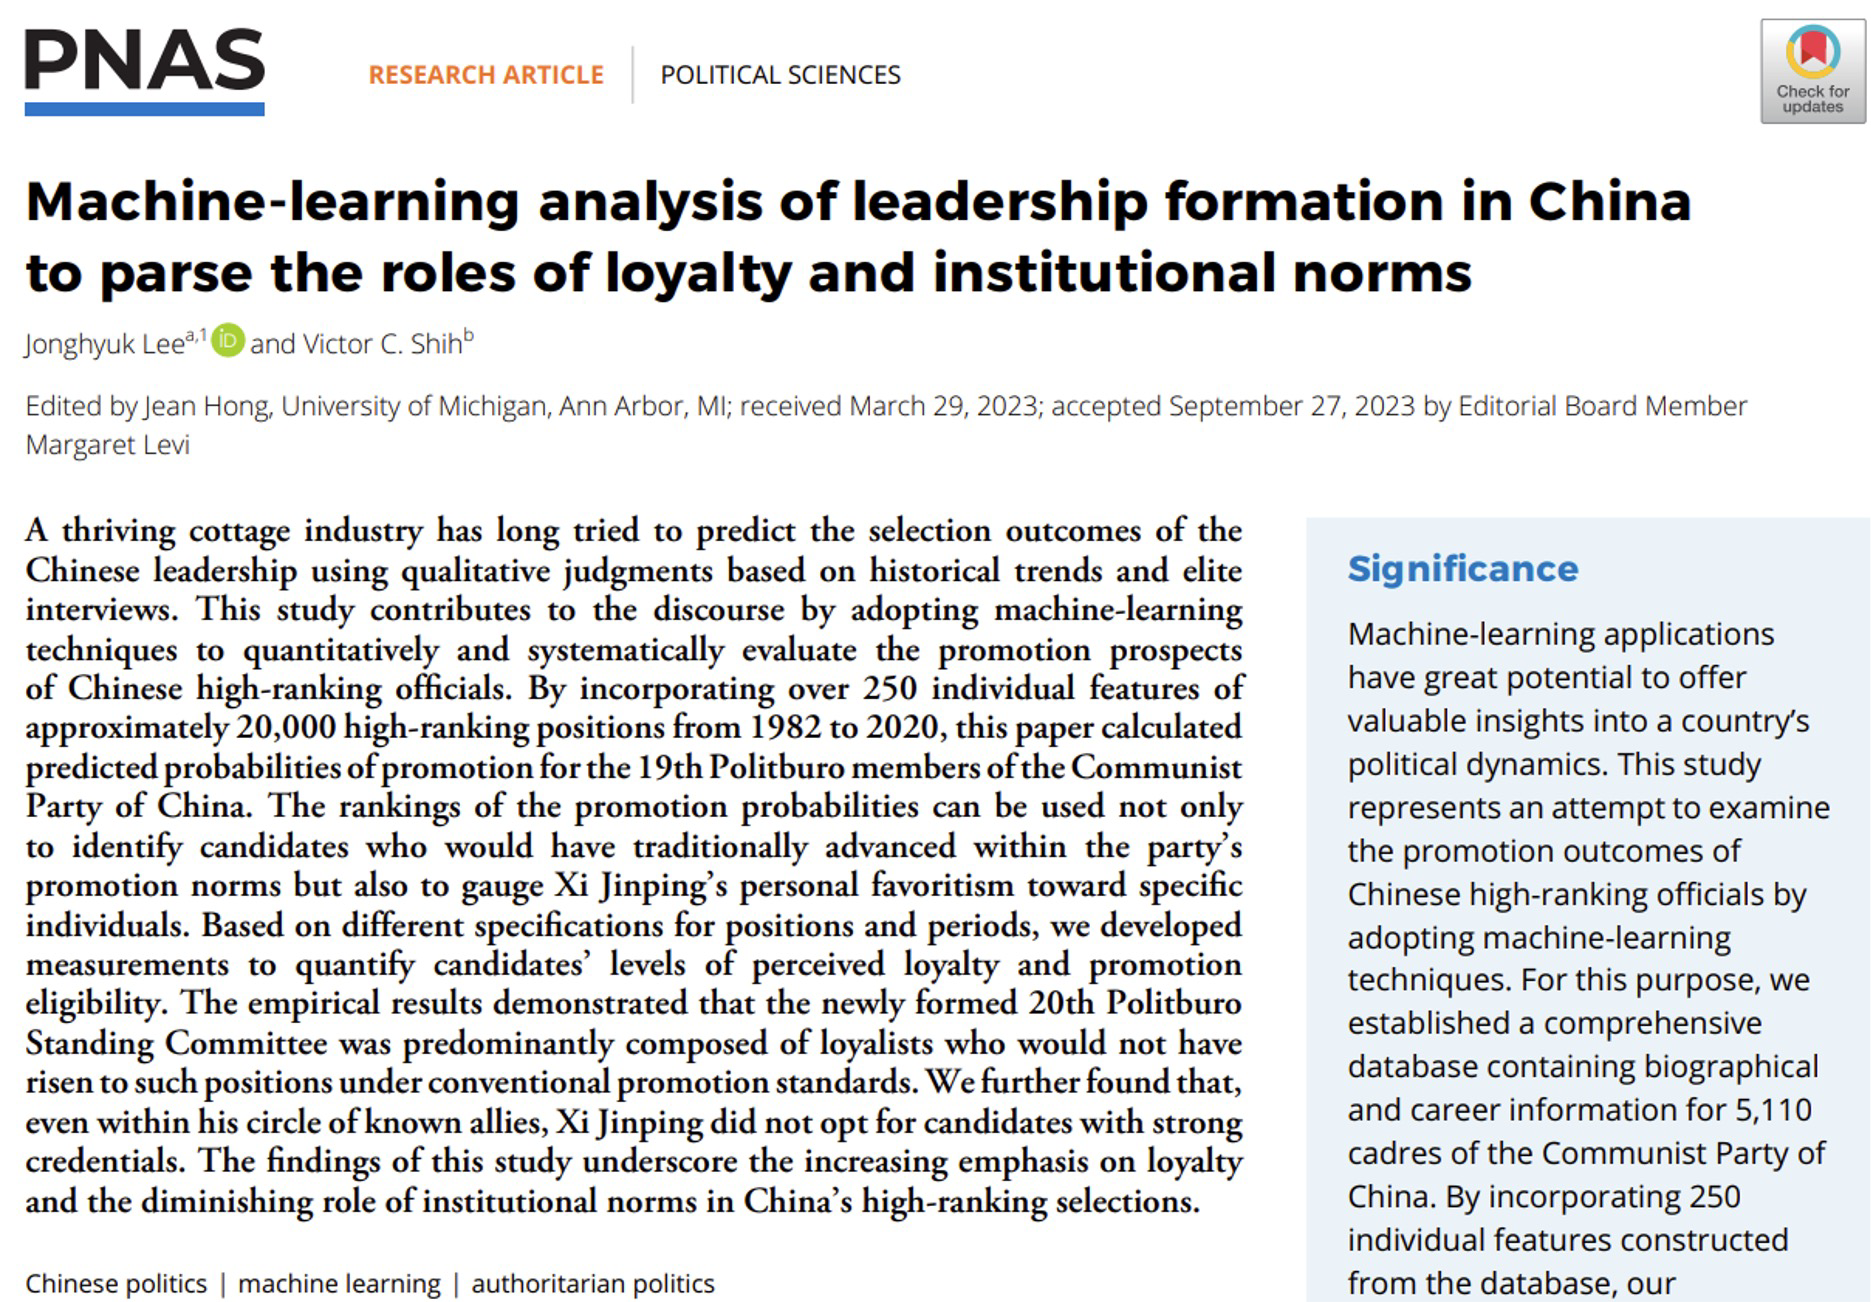


**Table of Contents**

1. Topic modelling in English and Chinese

  Classification models:
   
   - Data Input: Define X and y; Handling missing values; Training and testing sets
   - Data Processing: Define and Train model
   - Data output: Evaluate and interpret models

2. Logistic Regression

3. Decision Tree

4. Random Forest

5. Model Evaluations


### 1. Topic Modeling

Topic modeling is to summarize a corpus into themes. As basic units of documents, words are sometimes too small to characterize these themes. Therefore, we need a more powerful model that can more effectively summaroze documents into themes, with a collection of words.

Imagine topic modeling as a text highlighter tool. When you read through a paper, you might highlight those important words that are the gist of a document or paragraph. Topic modeling basically does that. It groups words that are related to each other under an umbralla, i.e., a topic. It presents you with the collection of words that are grouped together and it is up to you to interpret what the topic is about. Make sure you go back to the slides to see the screenshots and get a better idea.

Topic Modeling is a model for text analysis that generates insights under the above assumptions. Here is its required inputs and outputs:

**Required Inputs**

* Tokenized documents

* (IMPORTANT) Number of topics (K), predefined by researchers like you and me. Machines are just machines. They just perform whatever we tell them to using built in algorithms. We need to rough estimation of how many topics we are looking for, and revise them after seeing preliminary results, if necessary.

**Outputs**

* A set of topics, each represented by its most relevant words

* (for each document) a K-dimensional vector indicating its relevance to each of the K topics


The assumed Behavioral Model of topic modeling:

It is called "behavioral" because it tries to mimic what does the author do when they generate a document: When an “author” writes a document (e.g., MoFA question, answer, tweet), they:

* Have a vocabulary in mind

* Have a set of “topics” in mind

* Know how the vocabulary is associated with the “topics”

* Pick the proportions that each “topic” should take in the document

* Pick words according to the proportions of topics

* Generate the document, which is a bag of words

IMPORTANT: You need to understand this to interpret topic modeling correctly


Let's do it. We first import another useful function, i.e., LDA. Remember we talked about the two myths? One of them is that we won't touch on how these models work. This is one of the models. The exact mathmatical implementation of this function is complex and beyond the scope of this course, although you are welcome to search for more information about LDA and how it works. https://en.wikipedia.org/wiki/Latent_Dirichlet_allocation

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

Then, initiate the model. `n_components` controls the number of topics. `random_state` controls the random seed it generates everytime you call the function. If you want to generate replicable LDA models, pass in an interger to make the random state fixed.

In [ ]:
model_lda = LatentDirichletAllocation(n_components=20, random_state=0)

And we fit the model. Fitted model has a light blue color. If there are errors that lead to a failure, you may need to review the previous steps.

In [ ]:
model_lda.fit(docs_bow)

LatentDirichletAllocation(n_components=20, random_state=0)

To plot the result of topic modeling, we need this chunk of customized function. For now, we don't need to understand completely how this function works. But therer are some parameters you can manipulate for your project.

In [ ]:
def plot_topic_top_words(model, feature_names, n_top_words, title, fig_n_row, fig_n_col):
    fig, axes = plt.subplots(fig_n_row, fig_n_col, figsize=(30, 15), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30}) # Font size
        ax.tick_params(axis="both", which="major", labelsize=20) # Label size
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)
    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()


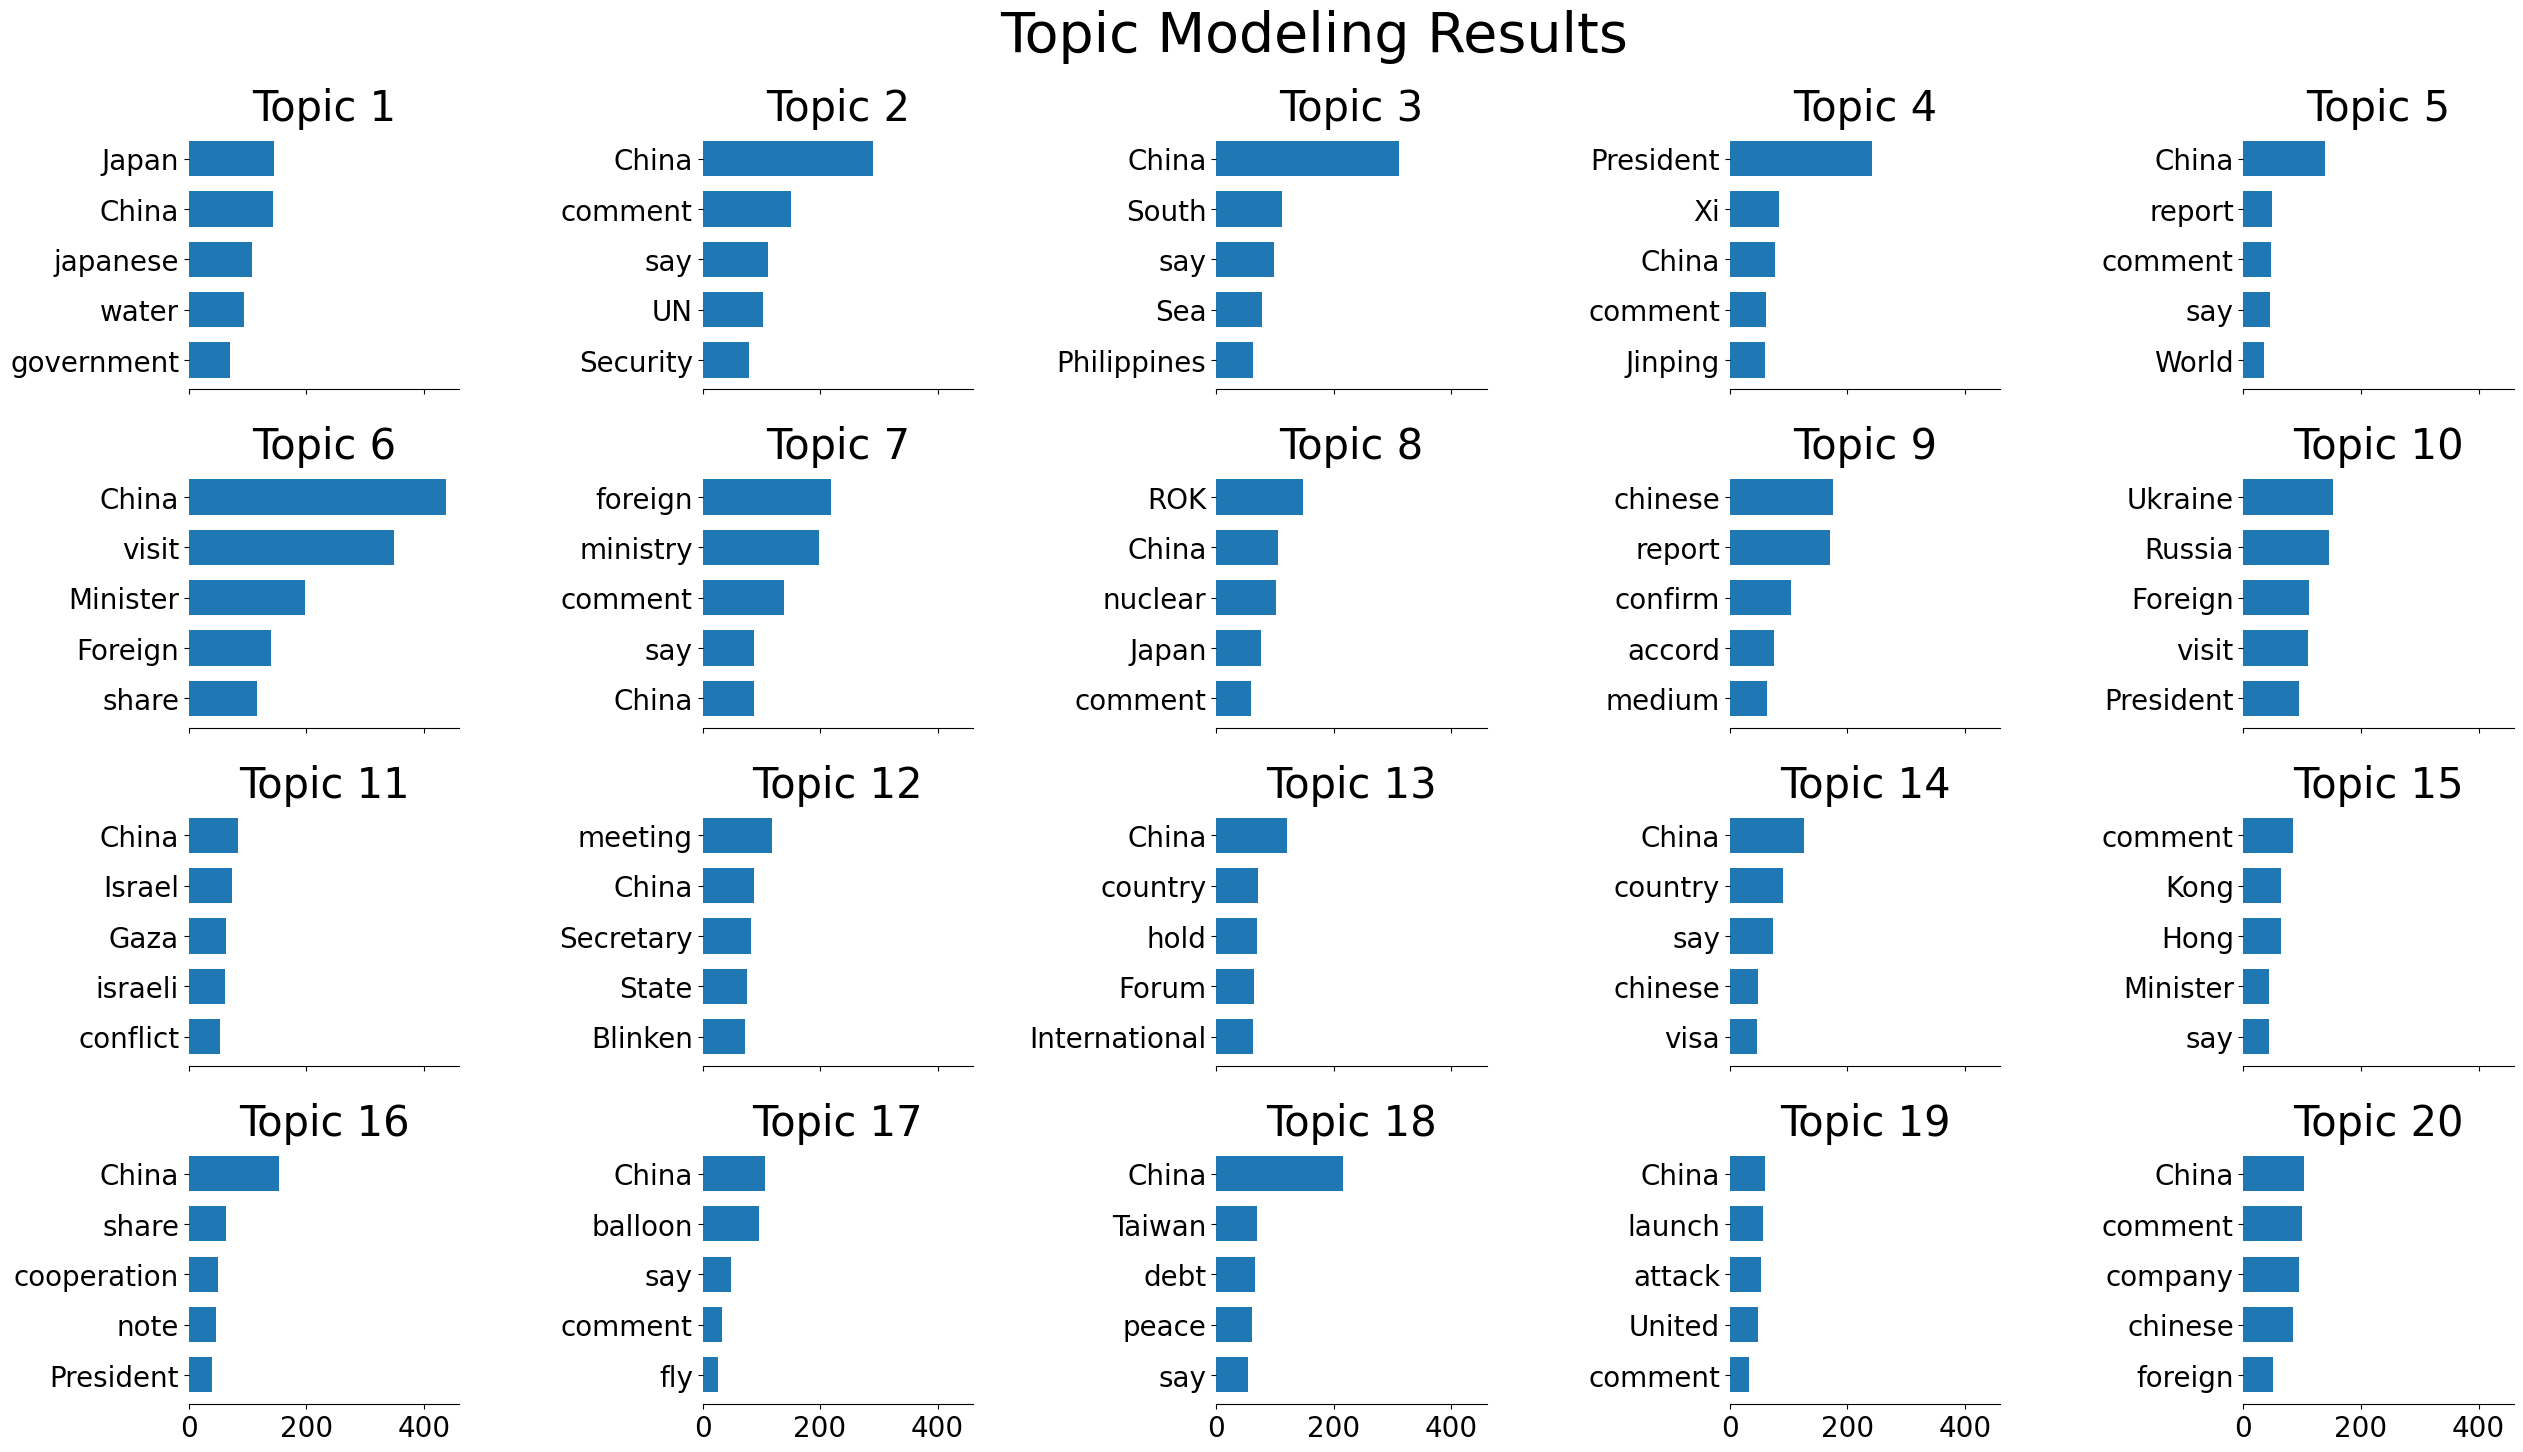

In [ ]:
plot_topic_top_words(model_lda, docs_vocab, 5, "Topic Modeling Results", 4, 5)

**Customizations**

If you want to change the number of topics, you need to fit the LDA model again with a new integer for the `n_components` argument. And you will also need to change the last two arguments for the `plot_topic_top_words()` function, their multiplication should match `n_components`.

In many cases, we might need to improve the result of this modeling by changing some parameters in the functions.

Improve topic modeling to make it more interpretable

* Observe and remove words that appear to make topics uninformative

* Change the number of topics?

* Concatenate named entities

Improve visualization

* Name the topics

* Names of topics on the data visualization

* Keep only topics that you can name?


### 2. Apply Text Analysis Skills to a Different Language, e.g., Chinese

Skills for Text Analysis is Generalizable. Languages look different. But computational approach to them are transferable.

Text analysis methods are usually developed and tested with reference to one or a few language(s) (most frequently, English, and somewhat frequently, Chinese). When you find a method useful for analyzing texts in one language, you are likely to find it useful for other languages. Algorithms for feature extraction (linguistic, substantive) are more often language-specific. But large toolkits provides workflow applicable across languages (e.g., spaCy). Large Language Models, as the latest development, show much improved multi-lingual capacity -- but the cost is they consume more computational resources.


Let's try Chinese. Since this is the first time we use the Chinese model, we need to download it before loading the model.

In [ ]:
spacy.cli.download("zh_core_web_sm")
nlp = spacy.load("zh_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Let's give it a test run.

In [ ]:
doc_test = nlp('SpaCy也能处理中文！ SpaCy can process Chinese too!')
for token in doc_test:
    print(token.text, token.pos_)

SpaCy PROPN
也 ADV
能 VERB
处理 VERB
中文 NOUN
！ PUNCT
SpaCy PROPN
can VERB
process NOUN
Chinese PROPN
too ADV
! PUNCT


Or maybe also French?

In [ ]:
# Load SpaCy tool for French
spacy.cli.download("fr_core_news_sm")
nlp_fr = spacy.load("fr_core_news_sm")

Caveat: Linguistic features that we can generate for English need not be available for other language. For example, there is no lemmatization for Chinese.
Read the documentation. But the documentation is not always informative. Poke around. Try.

We merged the Chinese and English versions of a part of the questions
(special thanks to our TA, Mr. Liao Li).

Let's perform the same analyses for all steps that follow:

* Extracting linguistic features

* Extracting named entities

* Visualize word frequencies

* Turn text into numbers using a BoW approach

* Make word clouds

* Perform Topic Modeling

Let’s try a few steps together!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/POLI3148/Week10/data_raw/MoFA_bilingual.csv')

In [ ]:
df.head()

,id,link,spokesperson_en,question_en,answer_en,who_asked_en,spokesperson_cn,question_cn,who_asked_cn,answer_cn
0,20752,https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s...,Hua Chunying,Some officials in a handful of countries inclu...,"At present, COVID-19 is ravaging across the wo...",China Review News,华春莹,近期，美国等个别国家有官员将本国疫情暴发的责任“甩锅”给中国，指责中国隐瞒实际感染数量，传播...,香港中评社,当前新冠肺炎疫情在世界范围蔓延扩散，特别是欧美一些国家形势严峻。各国人民一致呼吁要加强团结合...
1,20753,https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s...,Hua Chunying,"In a recent interview, White House trade advis...",The lies told by this US politician are not wo...,CCTV,华春莹,据报道，美国白宫国家贸易和制造业政策办公室主任纳瓦罗不久前接受采访时称，中国12月中旬已出现...,中央广播电视总台央视,这个美国政客信口雌黄，不值一驳。我注意到连当时采访他的美国记者都打断他的话，指出他是在浪费时...
2,20754,https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s...,Hua Chunying,The US State Department Spokesperson said yest...,"Since the epidemic broke out, China, in an ope...",Beijing Daily,华春莹,美国务院发言人30日称，蓬佩奥国务卿当日同北约秘书长斯托尔滕贝格通话，谈及反击中国传播与新冠...,北京日报,我刚才说了，新冠肺炎疫情发生以来，中方始终本着公开、透明、负责任态度，及时向世卫组织以及包括...
3,20755,https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s...,Hua Chunying,A Japanese Maritime Self-Defense Force destroy...,"According to competent department, there was a...",Kyodo,华春莹,30号晚上，日本海上自卫队舰艇在东海海域与一艘中国渔船相撞，中方能否透露详细信息？,日本共同社,据向有关部门了解，昨天傍晚7：30左右，在中国浙江舟山以东东海海域发生了一艘中国渔船与日本自...
4,20756,https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s...,Hua Chunying,"As COVID-19 spreads all around the world, coun...",That's not at all true. China's fight against ...,China Daily,华春莹,新冠肺炎疫情正在全球迅速蔓延，各国对N95口罩等防疫物资需求很大。有人认为中国正在囤积防疫医...,中国日报,这个说法我完全不同意。当前，中国的疫情并没有结束，外防输入、内防反弹的压力很大，对相关医疗物...


Again, we examine a slice of the dataset to get a better idea.

In [ ]:
df.loc[0, :].to_dict()

{'id': 20752,
 'link': 'https://www.fmprc.gov.cn/mfa_eng/xwfw_665399/s2510_665401/2511_665403/t1764277.shtml',
 'spokesperson_en': 'Hua Chunying',
 'question_en': 'Some officials in a handful of countries including the US have been trying to blame China for the pandemic outbreak, accusing China of covering up the actual caseload of the infected and disseminating disinformation on COVID-19. They also said that they will reckon with China after the pandemic passes. What is your response?',
 'answer_en': 'At present, COVID-19 is ravaging across the world, especially in Europe and the US. People of all countries have called for unity to fight the pandemic, but still some people have made jarring noises from time to time, quite discordant with the current atmosphere of unity against the pandemic. I want to stress a few points. As the coronavirus is novel virus unseen in the past, its detection, research, testing and confirmation naturally requires time. According to reports, on December 27,

In [ ]:
text = df.loc[0, 'answer_cn']
text

'当前新冠肺炎疫情在世界范围蔓延扩散，特别是欧美一些国家形势严峻。各国人民一致呼吁要加强团结合作，共同应对疫情。但同时，就像你刚才讲的，有个别人不时发出一些刺耳声音，跟当前国际社会团结抗疫的气氛十分不和谐。我想强调几点：新冠肺炎病毒作为一种人类前所未见的新型病毒，从发现、研究、检测到确定都需要一定时间。据报道，2019年12月27日，湖北省中西医结合医院呼吸与重症医学科主任张继先第一时间上报了她接诊的3个可疑病例，29日湖北省和武汉市卫健委指示相关疾控中心和医院开展流行病学调查，30日武汉市卫健委发布关于《做好不明原因肺炎救治工作的紧急通知》，12月31日国家卫健委专家组抵达武汉开展现场调查。2020年1月3日中方开始正式向世卫组织以及包括美国在内的世界各国及时主动通报信息，11日中国疾控中心将5条新冠病毒全基因组序列上传网站，同全球和世卫组织共享数据，1月23日，中方采取了关闭离汉通道等空前全面、彻底和严格的措施。中国政府第一时间采取了果断有力的措施，全国人民团结一心、众志成城，最大程度地保护了中国人民的生命安全和身体健康。根据世卫组织评估，中国政府采取的果断、有力、及时措施，避免了数10万人感染。许多国家也都认为，中国的经验做法为其他国家提供了有益借鉴。中国政府秉持的公开、透明和负责任的态度，得到了国际社会的高度赞誉。我们无意评判其他国家应对疫情的表现，但是正如世卫组织和很多国家领导人及专家、国际媒体所说，中国此次疫情应对为世界争取了宝贵的时间。但有关国家到底有没有充分利用中国作出巨大努力和牺牲争取来的宝贵时间窗口期，我想相关国家政府是清楚的，人民也是能切身体会到的。就美国而言，1月3日中方就已经开始正式定期向美方通报分享有关信息。1月7日美国疾控中心和美国驻华使馆就已经发出了赴武汉旅行的健康警告，1月25日美方就宣布关闭驻武汉领馆并撤出其人员。2月2日美国政府就已经对所有中国公民和过去14天到过中国的外国人关闭边境。这么多天过去了，美方还有人在叫嚣，让中国为美国疫情负责，他们难道不心虚、不愧疚吗？这些人试图制造一只世界上最大的锅甩给中国，让中国成为最大的替罪羊。但是，这个锅太大了，对不起，他们甩不出去的。疫情是面照妖镜，人心善恶、品行高低尽显其中，一览无余。病毒不讲意识形态，也不分国家种族。面对疫情，各国命运与共，污蔑攻击、甩锅推责都弥补不了失去的时间，唯有加

In [ ]:
doc = nlp(text)

Let's reuse the previous function for extracting linguistic features.

In [ ]:
features_ling = pd.DataFrame(
    {
        "token": [word.text for word in doc],
        "lower": [word.lower_ for word in doc],
        "lemma": [word.lemma_ for word in doc],
        "pos": [word.pos_ for word in doc],
        "stopword": [word.is_stop for word in doc],
    }
)

As there is no lemmatization for Chinese, the lemma column is left empty.

In [ ]:
features_ling

,token,lower,lemma,pos,stopword
0,当前,当前,,NOUN,True
1,新冠,新冠,,PROPN,False
2,肺炎,肺炎,,NOUN,False
3,疫情,疫情,,NOUN,False
4,在,在,,ADP,True
...,...,...,...,...,...
711,、,、,,PUNCT,True
712,共同,共同,,ADV,True
713,应对,应对,,VERB,False
714,疫情,疫情,,NOUN,False


Similarly, the named entity extraction also uses the previously defined function.

In [ ]:
features_ne = pd.DataFrame(
    {
        'ne': [ne.text for ne in doc.ents],
        # 'ne_lemma': [ne.lemma_ for ne in doc.ents],
        'ne_label': [ne.label_ for ne in doc.ents],
        'ne_start': [ne.start for ne in doc.ents],
        'ne_end': [ne.end for ne in doc.ents],
        'ne_start_char': [ne.start_char for ne in doc.ents],
        'ne_end_char': [ne.end_char for ne in doc.ents],
    }
)

In [ ]:
features_ne.head(10)

,ne,ne_label,ne_start,ne_end,ne_start_char,ne_end_char
0,欧美,LOC,11,12,21,23
1,2019年12月27日,DATE,95,98,155,166
2,湖北省,GPE,99,100,167,170
3,张继先,PERSON,108,109,187,190
4,第一时间,ORDINAL,109,110,190,194
5,3,CARDINAL,115,116,201,202
6,29日,CARDINAL,120,121,208,211
7,湖北省,GPE,121,122,211,214
8,武汉市卫健委,ORG,123,125,215,221
9,30日,DATE,135,136,241,244


Examining the most frequency words for plotting word clouds.

In [ ]:
word_frequency = features_ling.token.value_counts().reset_index()
word_frequency.head(10)

,token,count
0,，,50
1,的,32
2,。,23
3,中国,15
4,和,15
5,、,13
6,了,13
7,国家,10
8,疫情,9
9,就,7


In [ ]:
word_frequency_s = word_frequency[word_frequency['count'] >= 3]

In [ ]:
word_frequency_dict = word_frequency_s.set_index("token").to_dict()['count']
word_frequency_dict

{'，': 50,
 '的': 32,
 '。': 23,
 '中国': 15,
 '和': 15,
 '、': 13,
 '了': 13,
 '国家': 10,
 '疫情': 9,
 '就': 7,
 '不': 7,
 '人民': 6,
 '政府': 6,
 '美国': 6,
 '中方': 6,
 '国际': 5,
 '1月': 5,
 '时间': 5,
 '是': 5,
 '各国': 4,
 '在': 4,
 '世界': 4,
 '大': 4,
 '团结': 4,
 '也': 4,
 '应对': 4,
 '世卫': 4,
 '病毒': 4,
 '组织': 4,
 '合作': 4,
 '已经': 3,
 '开展': 3,
 '中心': 3,
 '健康': 3,
 '疾控': 3,
 '美方': 3,
 '最': 3,
 '为': 3,
 '生命': 3,
 '都': 3,
 '措施': 3,
 '关闭': 3,
 '人': 3,
 '采取': 3,
 '这么': 3,
 '武汉': 3,
 '向': 3,
 '有': 3,
 '加强': 3,
 '有关': 3}

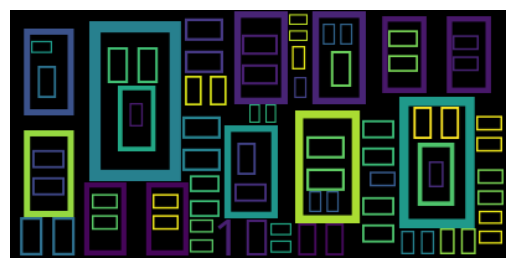

In [ ]:
wordcloud = WordCloud()
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Okay, that was a pretty long unannotated chunk of code. Were you able to keep up and remembered what each steps was for?

Now we see that these Chinese characters are not properly shown. It is because there is no font builtin to show them. Wee need to manually download to somehwere in our Googl Drive, keep it there, and specify the path for Python to use.

In [ ]:
PATH_FONT = '/content/drive/MyDrive/POLI3148/Week10/data_chinese_font/simhei/SimHei.ttf'

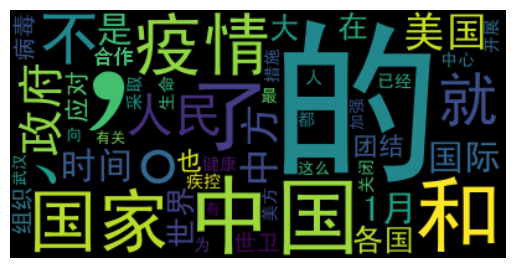

In [ ]:
wordcloud = WordCloud(font_path = PATH_FONT)
wordcloud.generate_from_frequencies(word_frequency_dict)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Not it looks pretty good. We only need to remove those punctuations and stopwords. You remember how to do that? By filtering out rows that contains the undesired words!

**Your turn**

Remove the stopwords and punctuations, and plot a replicable Chinese word cloud.

In [ ]:
# Insert codes below

If you also want to plot the distribution of words using Seaborn, you may also need specify the font path.

In [ ]:
word_frequency_s2 = word_frequency_s[word_frequency_s['count'] >= 5]

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python

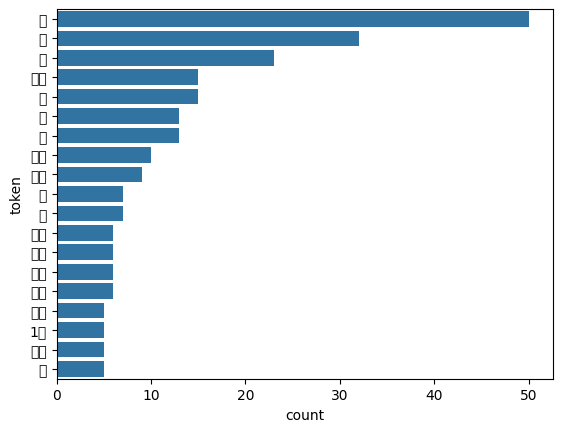

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
sns.barplot(word_frequency_s2, y = "token", x = "count")
plt.yticks()
plt.show()

In [ ]:
font_cn = matplotlib.font_manager.FontProperties(fname = PATH_FONT)

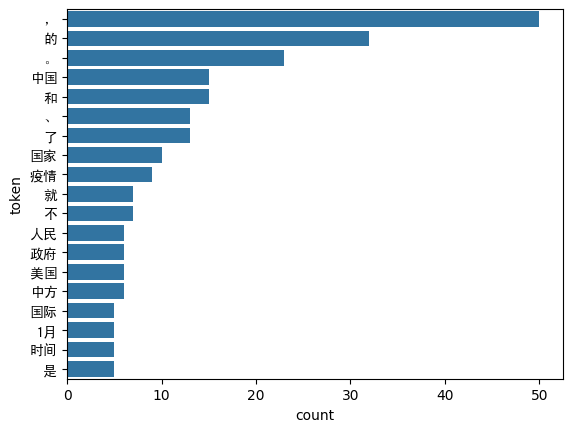

In [ ]:
sns.barplot(word_frequency_s2, y = "token", x = "count")
plt.yticks(fontproperties = font_cn) # This is the trick
plt.show()

You can follow along the codes we did for English to to topic modeling for Chinese.

We have covered:

The ABC of text analysis

* A selected set of tools that I found rigorous

* Basic methods that I found helpful

* Intuitions of some “fundamentals” underlying these methods

What we have not covered

* Technical details (mathematical proofs, engineering)

* A lot of other tools available

* Tools come and go. What is important is: You understand the logic of the “fundamentals” (e.g., the BoW approach). And You acquire the mindset that helps you understand the “fundamentals”.


There are other tools that can perform the text analysis we have done in the past two sessions.

For textual feature extraction: NLTK

For topic modeling: Gensim

I choose a small set of tools to demonstrate how things work and how to do it in an efficient way. To share generalizable knowledge under time constraint, I am very selective, and cover only a few.
Feel free to explore other tools. But beware of the quality and suitability for your tasks of interest.


### 3. Machine Learning for Classification: Logistic Regression

**Machine Learning**

What is Machine Learning?

Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Advances in the field of deep learning have allowed neural networks to surpass many previous approaches in performance.

**What do social scientist care about machine learning?**

- Discover complex relationship in big data

- Automate data annotation tasks

- Make causal inferences

**Essentials of Machine Learning: What matters**

- Transform data to make them machine-readable

- Train Machine Learning models

- Evaluate Machine Learning models

- Interpret Machine Learning models

**Classiﬁcation Model**

Definition: A model whose prediction is a class. For example, the following are all classification models:

- A model that predicts an input sentence's language (French? Spanish? Italian?).

- A model that predicts tree species (Maple? Oak? Baobab?).

- A model that predicts the positive or negative class for a particular medical condition.

- A model that predicts if an official can get promotion

- A model that predicts if a war will happen

- A model that predicts which candidate can win the election

In contrast, regression models predict numbers rather than classes.

**Classiﬁcation Model: Binary versus Multi-class**

- Binary Classification: Outcomes can only be one of two states, for example:

An official gets promotion or not A war happens or not A candidate wins or loses

- Multi-Class Classification: Outcomes can be in one of multiple states, for example:

An official gets promoted, demoted, or stay in the position No conflict, a non-violent conflict, or a violent conflict A Democratic, Republican, or Independent candidate wins

We focus on **Binary Classification** in this lecture, using the case: Lee & Shih (2023).

**Workflow**

1. Data Input:
   
    Load data

    Define X and y

    Handle missing values

    Split data into training and test sets

    Re-formats for Machine Learning tool

2. Data Processing:
   
   Define model
   
   Train model

3. Data Output:
   
   Evaluate model
   
   Interpret model
   
   Discussion: What your results say about the substantive topics

A special case for this lecture: We are loading RData, because the authors performed their analysis using R and stored the data in this special format. Therefore, we need a module to read it.

In [ ]:
!pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
import os
import pyreadr

# Machine Learning Module
from sklearn.model_selection import train_test_split

In [ ]:
PATH_PROJECT = "/content/drive/MyDrive/POLI3148/Week11/machine_learning_1"

In [ ]:
# Set the working directory to your project path
os.chdir(PATH_PROJECT)

In [ ]:
# Read in the data
df = pyreadr.read_r("data_raw/data_train_2020_DEC.RData")

In [ ]:
df.keys()

odict_keys(['data_training'])

In [ ]:
df = df['data_training']

Let's overview a bit of the data, as always.

In [ ]:
df

,promo,pc,year,posi,age,age2,age60over,age61over,age62over,age63over,...,PAT_POLI_all5_promo_cur_dum,PAT_POLI_all_stay_cur_dum,PAT_POLI_all5_stay_cur_dum,PAT_POLI_all_removal_cur_dum,PAT_POLI_all5_removal_cur_dum,PAT_POLI_all_arrest_cur_dum,PAT_POLI_all5_arrest_cur_dum,NC_degc,NC_btwc,NC_cloc
0,0.0,15.0,1997.0,Center,55.0,3025.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95.0,403.909991,0.000103
1,0.0,17.0,2007.0,Center,65.0,4225.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,95.0,403.909991,0.000103
2,0.0,16.0,2002.0,Center,60.0,3600.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,95.0,403.909991,0.000103
3,0.0,18.0,2012.0,Center,61.0,3721.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,159.0,2773.371302,0.000110
4,0.0,17.0,2007.0,Center,56.0,3136.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,159.0,2773.371302,0.000110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20134,0.0,19.0,2020.0,Prov,58.0,3364.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,968.989276,0.000106
20135,0.0,19.0,2020.0,Prov,59.0,3481.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,12.067003,0.000087
20136,0.0,19.0,2020.0,Prov,57.0,3249.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,138.0,863.417759,0.000110
20137,0.0,19.0,2020.0,Prov,49.0,2401.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,241.032708,0.000102


In [ ]:
df.shape

(20139, 251)

Our outcome variable of interest is whether or not the official get promoted. 1 here stands for successful promotion, and 0 stands for not.

In [ ]:
# Outcome variable of interest
df.promo.value_counts()

,count
promo,
0.0,18458
1.0,1679


Then we select some predictors for promotion. We include age, gender, ethnicity, eudcation, previous work experience in Fujian, etc. There are more predictors in the data, you may choose ones that you are interested in.

In [ ]:
# A subset of predictors of interest
df.loc[:, ['age', 'gender', 'ethnic', 'edu', 'prov_FJ', 'ten', 'noflt', 'princeling']]

,age,gender,ethnic,edu,prov_FJ,ten,noflt,princeling
0,55.0,0,1,2,0.0,4.0,1.0,0.0
1,65.0,0,1,2,0.0,4.0,1.0,0.0
2,60.0,0,1,2,0.0,9.0,1.0,0.0
3,61.0,0,0,3,0.0,5.0,0.0,0.0
4,56.0,0,0,3,0.0,40.0,0.0,0.0
...,...,...,...,...,...,...,...,...
20134,58.0,0,0,3,0.0,3.0,1.0,0.0
20135,59.0,0,0,3,0.0,4.0,1.0,0.0
20136,57.0,0,0,2,0.0,5.0,1.0,0.0
20137,49.0,0,0,3,0.0,4.0,1.0,0.0


**Identify X and y**

y: namely, outcome/ target/ dependent variable

X: namely, oredictors, features, independent variables

In [ ]:
y_name = ['promo']
X_names = ['age', 'gender', 'ethnic', 'edu', 'ten', 'noflt', 'princeling']

In [ ]:
y_name + X_names

['promo', 'age', 'gender', 'ethnic', 'edu', 'ten', 'noflt', 'princeling']

In [ ]:
df_s = df.loc[:, y_name + X_names]

In [ ]:
df_s

,promo,age,gender,ethnic,edu,ten,noflt,princeling
0,0.0,55.0,0,1,2,4.0,1.0,0.0
1,0.0,65.0,0,1,2,4.0,1.0,0.0
2,0.0,60.0,0,1,2,9.0,1.0,0.0
3,0.0,61.0,0,0,3,5.0,0.0,0.0
4,0.0,56.0,0,0,3,40.0,0.0,0.0
...,...,...,...,...,...,...,...,...
20134,0.0,58.0,0,0,3,3.0,1.0,0.0
20135,0.0,59.0,0,0,3,4.0,1.0,0.0
20136,0.0,57.0,0,0,2,5.0,1.0,0.0
20137,0.0,49.0,0,0,3,4.0,1.0,0.0


**Handling missing values**

In [ ]:
df_s.isnull().sum()

,0
promo,2
age,379
gender,0
ethnic,0
edu,0
ten,2
noflt,34
princeling,0


In [ ]:
# Proportion of missing rows (over total number of rows)
df_s.isnull().mean()

,0
promo,0.000099
age,0.018819
gender,0.000000
ethnic,0.000000
edu,0.000000
ten,0.000099
noflt,0.001688
princeling,0.000000


Missing values can cause problem with your machine modeling. Handle them before passing your data to machine learning models. We use a simplest approach -- removing rows that contains missing values. Alternatively, you may use imputation to fill in missing values.

Since there are not a lot of missing values, we may drop them, which should not cause a lot of troubles.

In [ ]:
df_s_dropna = df_s.dropna()

In [ ]:
df_s_dropna

,promo,age,gender,ethnic,edu,ten,noflt,princeling
0,0.0,55.0,0,1,2,4.0,1.0,0.0
1,0.0,65.0,0,1,2,4.0,1.0,0.0
2,0.0,60.0,0,1,2,9.0,1.0,0.0
3,0.0,61.0,0,0,3,5.0,0.0,0.0
4,0.0,56.0,0,0,3,40.0,0.0,0.0
...,...,...,...,...,...,...,...,...
20134,0.0,58.0,0,0,3,3.0,1.0,0.0
20135,0.0,59.0,0,0,3,4.0,1.0,0.0
20136,0.0,57.0,0,0,2,5.0,1.0,0.0
20137,0.0,49.0,0,0,3,4.0,1.0,0.0


**Turn your X and y into Numpy Arrays**

Turn your data into a format that is Sklearn can process efficiently (and with lower likelihood of errors)

To add to the “preamble” chunk where you load all the libraries, you should write the `import numpy as np` at the very beginning of your notebook.

In [ ]:
X = df_s_dropna.loc[:, X_names].to_numpy()
X

array([[55.0, '0', '1', ..., 4.0, 1.0, 0.0],
       [65.0, '0', '1', ..., 4.0, 1.0, 0.0],
       [60.0, '0', '1', ..., 9.0, 1.0, 0.0],
       ...,
       [57.0, '0', '0', ..., 5.0, 1.0, 0.0],
       [49.0, '0', '0', ..., 4.0, 1.0, 0.0],
       [60.0, '0', '0', ..., 4.0, 2.0, 0.0]], dtype=object)

In [ ]:
y = df_s_dropna.loc[:, y_name].to_numpy()
y

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [ ]:
y = y[:, 0]
y

array([0., 0., 0., ..., 0., 0., 0.])

**Before fitting your data**

Check your constructed data. They should be:

- No missing value

- All columns are numeric

- Keep x_names for future use

**Split Data into Training and Test Sets**

20% of the data are put in a “held-out” test set.

**Why?**

A key objective of Machine Learning is to perform prediction

- We want to know how well a model performs if it is given new data it has not seen before

- E.g., in our case, we are interested in knowing how well our Model can take the profile of a new official and predict how likely they will get promoted

**How do we get an idea of “how well?”**

- Hide a part of the data (X_test, y_test) from the Machine Learning model

- Train the Machine Learning model using only a part of our data (X_train, y_train)

- Apply the Machine Learning model to the “hidden” data (X_test) to get predictions (y_test_predicted), pretending we don’t know the answer

- Compare Machine Learning model’s predictions (y_test_predicted) with the answer we already know (y_test). Their discrepancy tells us how well the model does

This works like a mock-test.

**Consequences of not splitting the data: “Over-fitting”**

It is the biggest consequence of training and evaluating the model in this manner.

Overfitting means creating a model that matches (memorizes) the training set so closely that the model fails to make correct predictions on new data. In other words, the model performs so well on this particular case that it cannot to be applied to other cases we might encounter in the future, essentially making the model useless.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 321)

In [ ]:
X_train

array([[48.0, '0', '0', ..., 3.0, 2.0, 0.0],
       [63.0, '0', '0', ..., 2.0, 3.0, 0.0],
       [53.0, '0', '0', ..., 3.0, 1.0, 0.0],
       ...,
       [61.0, '0', '0', ..., 6.0, 1.0, 0.0],
       [56.0, '0', '0', ..., 1.0, 1.0, 0.0],
       [60.0, '0', '0', ..., 1.0, 1.0, 0.0]], dtype=object)

In [ ]:
X_test

array([[59.0, '0', '0', ..., 7.0, 1.0, 0.0],
       [63.0, '0', '0', ..., 6.0, 1.0, 0.0],
       [49.0, '0', '0', ..., 1.0, 2.0, 0.0],
       ...,
       [52.0, '0', '0', ..., 1.0, 2.0, 0.0],
       [67.0, '0', '0', ..., 3.0, 1.0, 0.0],
       [54.0, '0', '0', ..., 1.0, 1.0, 0.0]], dtype=object)

In [ ]:
X_train.shape

(15806, 7)

In [ ]:
X_test.shape

(3952, 7)

**Define and train the model**

**What does “defining” and “training” an ML model mean?**

- An ML model has an “architecture” (and is named after it)

Mathematic equations specifying the relationship between data and parameters Engineering design on how to learn from the data to update the parameters, so that the model reflects the patterns of the data Simplest example: y = ax + b (“Linear Regression”)

- First, select the type (“architecture”) of model to use

- Second, initialized the model, with parameters randomly assigned

- Third, train the model with data to update the parameters

**But, how do these models work?**

- We don’t have time to discuss the “architecture” of the variety of ML models

- Focus on how to use these models in a advisable workflow with Python

- My requirement: When using a ML model

Must: Refer to models by its names properly Must: Report relevant information properly Strongly recommended: Attempt multiple models for the same data Preferred: Understand the intuition of the architecture of the models you use

**The tool: Sklearn**

THE most popular Python library for Machine Learning So popular that you can write it on your resume!

- We previously used it for text analysis

Constructing “Bag-of-word” tables Train topic modeling using the “Latent Dirichlet Allocation” function

-  Advantage: One standardized workflow for vavious types of ML models

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Initialize the ML model
model_lr = LogisticRegression()

In [ ]:
model_lr

LogisticRegression()

In [ ]:
# Train the ML model
model_lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
model_lr.coef_

array([[-0.05284073, -0.39219176, -0.43842458,  0.02623503,  0.06552536,
         0.32003672,  0.83882039]])

**Interpret and evaluate the model**

**Interpret Model**

Interpreting the ML model helps us understand the association between X and y

- Not all ML models are interpretable (in general, models with more complex architecture are less interpretable)

- Interpretable ML models need to be interpreted in different ways

- Logistic Regressions are interpretable

We can understand how each column in X is associated with y

In [ ]:
import pandas as pd

In [ ]:
model_interpretation = pd.DataFrame({"Predictor": X_names, "Coefficient": model_lr.coef_[0]})

In [ ]:
model_interpretation

,Predictor,Coefficient
0,age,-0.052841
1,gender,-0.392192
2,ethnic,-0.438425
3,edu,0.026235
4,ten,0.065525
5,noflt,0.320037
6,princeling,0.838820


In [ ]:
model_interpretation = model_interpretation.sort_values("Coefficient")

In [ ]:
import seaborn as sns

<Axes: xlabel='Coefficient', ylabel='Predictor'>

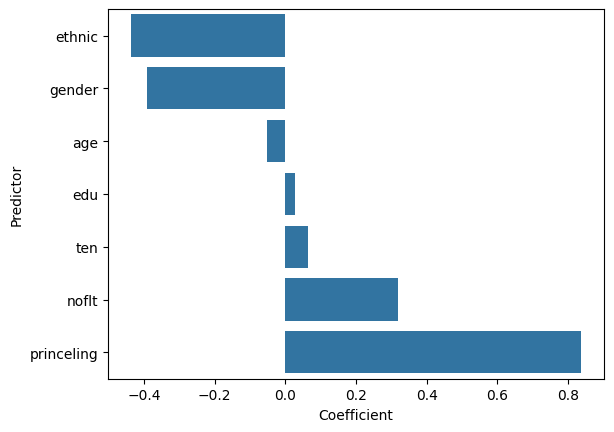

In [ ]:
sns.barplot(x = "Coefficient", y = "Predictor", data = model_interpretation)

In [ ]:
X_test

array([[59.0, '0', '0', ..., 7.0, 1.0, 0.0],
       [63.0, '0', '0', ..., 6.0, 1.0, 0.0],
       [49.0, '0', '0', ..., 1.0, 2.0, 0.0],
       ...,
       [52.0, '0', '0', ..., 1.0, 2.0, 0.0],
       [67.0, '0', '0', ..., 3.0, 1.0, 0.0],
       [54.0, '0', '0', ..., 1.0, 1.0, 0.0]], dtype=object)

**Evaluate Model**

- Evaluating a ML model tells us how well it perform with new data that it has never seen

- In our example, for officials whose profiles our model has never seen, how well does it predict their odds of promotion

- Make use of X_test and y_test

**Evaluate Classiﬁer 1: Make Prediction with New Data**

In [ ]:
# Evaluate the model
y_test_predicted_probability = model_lr.predict_proba(X_test)
y_test_predicted_probability

array([[0.91717975, 0.08282025],
       [0.93748265, 0.06251735],
       [0.87248417, 0.12751583],
       ...,
       [0.88910447, 0.11089553],
       [0.95753545, 0.04246455],
       [0.92465508, 0.07534492]])

In [ ]:
y_test_predicted_probability_1 = y_test_predicted_probability[:, 1]
y_test_predicted_probability_1

array([0.08282025, 0.06251735, 0.12751583, ..., 0.11089553, 0.04246455,
       0.07534492])

In [ ]:
y_test

array([0., 0., 0., ..., 0., 0., 0.])

**Binarize the Output – Select a Threshold**

This tells the machine: When the predicted probability of the positive case (e.g., being promoted) is greater to 0.2, I consider it as a positive prediction

In [ ]:
THRESHOLD = 0.20

In [ ]:
y_test_predicted = (y_test_predicted_probability_1 > THRESHOLD)
y_test_predicted

array([False, False, False, ..., False, False, False])

**Evaluate Classifier 2: Compare the Predicted and Actual Outputs**

Get a Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
from sklearn import metrics

In [ ]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[3571,   47],
       [ 316,   18]])

Get individual count numbers

In [ ]:
true_negative, false_positive, false_negative, true_positive = metrics.confusion_matrix(y_test, y_test_predicted).ravel()

In [ ]:
print(f"True Negative: {true_negative}")
print(f"False Negative: {false_negative}")
print(f"True Positive: {true_positive}")
print(f"False Positive: {false_positive}")


True Negative: 3571
False Negative: 316
True Positive: 18
False Positive: 47


Why so complicated? Can’t we have just one number? The complexity with evaluating a classification model

- A perfect ML model: All predictions true positive and true negative

- In reality: Trade-off

Increase true positive → increase false positive Increase true negative → increase false negative

- Different applications are more concerned about different types of error For example, if doctors develop a ML model for diagnostic, false negative results will be very costly

- Data scientist develop a set of evaluation metrics to summarize the performance of an ML model along different dimensions

**Evaluation Metrics**

Terms: “TP” = True positive; “FP” = False positive; “TN” = True negative; “FN” = False negative

- Accuracy: the prop. of all classifications that were correct (TP + TN) / (TP + TN + FP + FN)

- Precision: the prop. of all the model's positive classifications that are actually positive TP / (TP + FP)

- Recall (True Positive Rate): the prop. of all actual positives that were classified correctly as positives TP / (TP + FN)

- False Positive Rate: the prop. of all actual negatives that were classified incorrectly as positives FP / (FP + TN)

- F1 score (“average” of precision and recall): 2 * (Precision * Recall) / (Precision + Recall)

Let's calculate manually for once. But Sklearn provides functions to make the calculation convenient.

In [ ]:
# Accuracy
(true_negative + true_positive) / (true_negative + true_positive + false_negative + false_positive)

0.9081477732793523

In [ ]:
# Precision
precision = true_positive / (true_positive + false_positive)
precision

0.27692307692307694

In [ ]:
# Recall
recall = true_positive / (true_positive + false_negative)
recall

0.05389221556886228

In [ ]:
f1 = 2 * (precision * recall) / (precision + recall)
f1

0.09022556390977444

In [ ]:
metrics.accuracy_score(y_test, y_test_predicted)

0.9081477732793523

In [ ]:
from sklearn import metrics # add to preamble and run
print(metrics.accuracy_score(y_test, y_test_predicted))
print(metrics.precision_score(y_test, y_test_predicted))
print(metrics.recall_score(y_test, y_test_predicted))
print(metrics.f1_score(y_test, y_test_predicted))

0.9081477732793523
0.27692307692307694
0.05389221556886228
0.09022556390977443


Choice of Threshold can change all these metrics. We may want to write a function, see how changes in thresholds alter the evaluation metrics. So that we have an overview of what the model may perform under different thresholds.

**Towards A More Comprehensive Measure of Performance: The ROC Curve**

Evaluate a model’s quality across all possible thresholds

Receiver-operating characteristics curve (ROC curve)

Idea:

- Change the thresholds from 0 to 1

- Get the combination of True Positive Rate (Precision) and False Positive Rate at each threshold

- Plot them (X = FPR, Y = TPR). This is called the ROC curve

- Advanced: The Area Under the ROC curve (AUC) measures the model’s performance

Intuitively, AUC tells us, with the trade-off between true and false positive, how well can the model do.

**What you want the ROC curve look like for a great model?**

You want a threshold for you to balance true positive and false positive. There should be some kind of turning point where the curve ends its steep spike and starts to gently climb. Our ROC curve below is not so good by this standard.


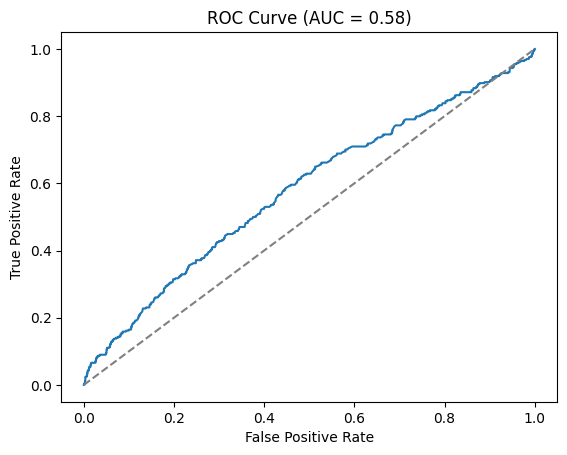

In [ ]:
auc = metrics.roc_auc_score(y_test, y_test_predicted_probability_1)
false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, y_test_predicted_probability_1)


import seaborn as sns
from matplotlib import pyplot as plt

plt.figure()
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {round(auc, 2)})')
plt.show()

Finally: Discussion of the ML Results

- Evaluating the model

How well does the model do in predicting new data?

- Interpreting the model

What does the parameters say about the associations in your data?

### 3. Decision Tree

**Define a Decision Tree Classifier**

In [ ]:
from sklearn import tree

model_dt = tree.DecisionTreeClassifier(random_state=0)

In [ ]:
model_dt

DecisionTreeClassifier(random_state=0)

**Train a Decision Tree Classiﬁer**

In [ ]:
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
X_names

['age', 'gender', 'ethnic', 'edu', 'ten', 'noflt', 'princeling']

**Visualize the decission tree**

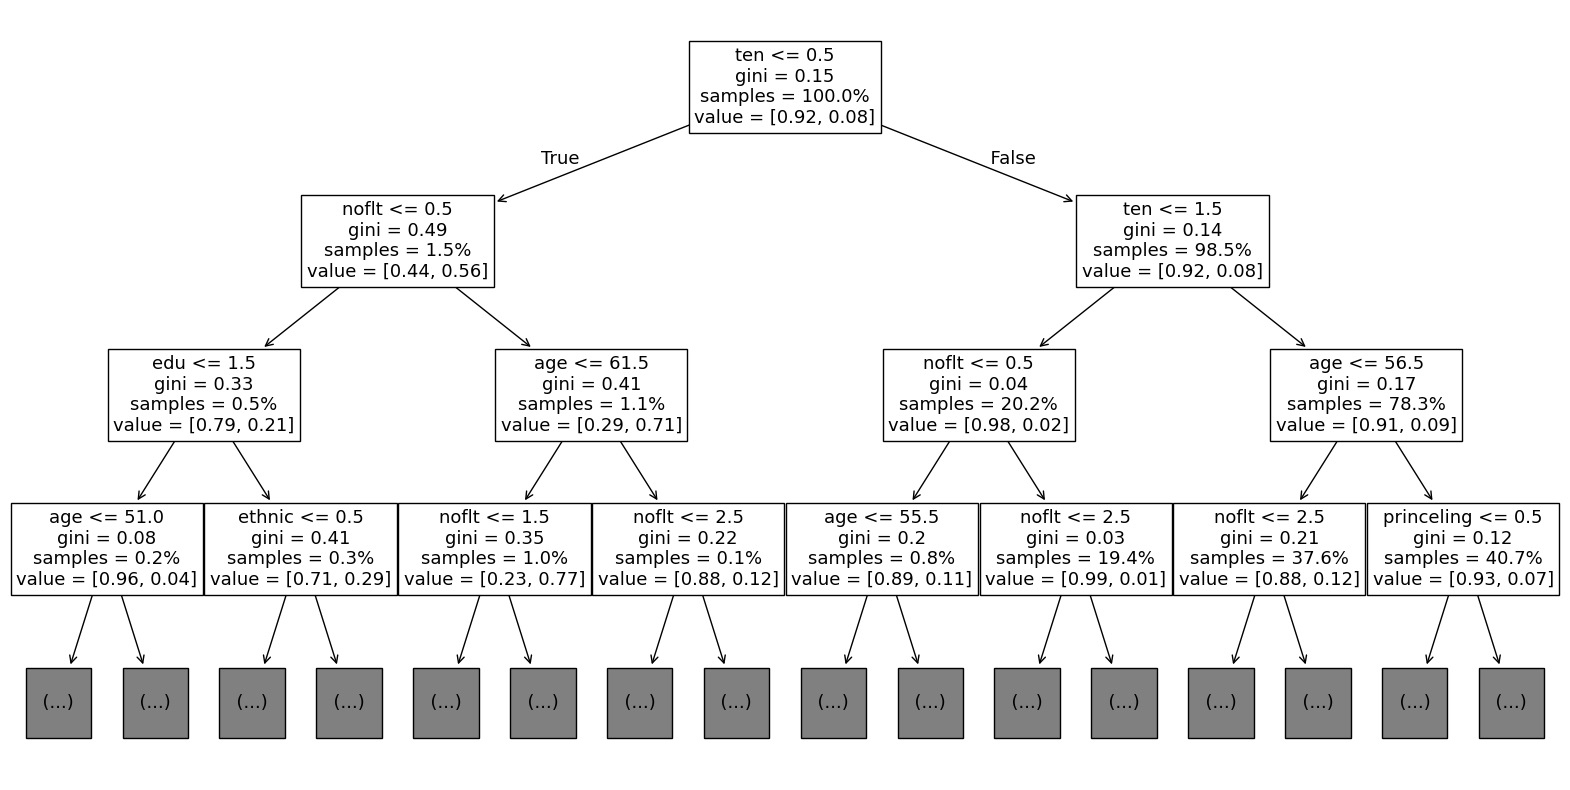

In [ ]:
plt.figure(figsize = (20, 10))
tree.plot_tree(model_dt, feature_names = X_names,
               max_depth = 3, fontsize = 13, proportion = True, precision = 2)
plt.show()


92% in class 0 (not promoted), 8% in class 1 (promoted)

And the Gini impurity is around 0.15.

Gini impurity: https://developers.google.com/machine-learning/glossary/df

**Interpret the Model: Feature Importance**

- Gini Impurity: the intuition

How “impure” is a branch. Ideally, we want a branch contains only one class. But that is not always the case. This indicates how impure the branch is.

Desired: a pure branch – everything under a branch is 1 (promoted) or 0 (not promoted) Ex: Age <= 56, ethnic minority, female, princelin ⇒ ALL gets promoted! (pure) Implausible and undesirable in real data analysis.

- There are exceptions, however well the tree is built

- Want to avoid over-fitting
  
-  Model attributes of interest: Feature Importance Measures how much a predictor reduces impurity


**Interpret Model: Obtain and Visualize Feature Importance**

Text(0.5, 1.0, 'Feature Importance of Decision Tree')

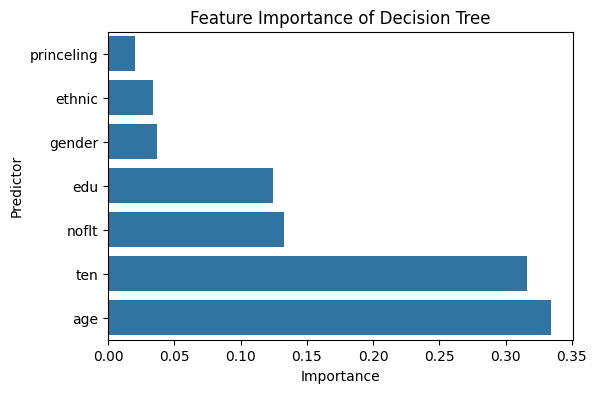

In [ ]:
model_interpretation = pd.DataFrame({"Predictor": X_names, "Importance": model_dt.feature_importances_})
model_interpretation = model_interpretation.sort_values("Importance")

plt.figure(figsize = (6, 4))
sns.barplot(y = "Predictor", x = "Importance", data = model_interpretation)
plt.title("Feature Importance of Decision Tree")


**Evaluate Model**

In [ ]:
THRESHOLD = 0.1
# Get predicted probability for the test set
y_test_predicted_probability = model_dt.predict_proba(X_test)
y_test_predicted_probability
y_test_predicted_probability_1 = y_test_predicted_probability[:, 1]
y_test_predicted = (y_test_predicted_probability_1 > THRESHOLD)
# Calculate Accuracy
print(f"Accuracy: {metrics.accuracy_score(y_test, y_test_predicted)}")
print(f"Precision: {metrics.precision_score(y_test, y_test_predicted)}")
print(f"Recall: {metrics.recall_score(y_test, y_test_predicted)}")
print(f"F1 Score: {metrics.f1_score(y_test, y_test_predicted)}")
print(f"ROC-AUC: {metrics.roc_auc_score(y_test, y_test_predicted_probability_1)}")


Accuracy: 0.7350708502024291
Precision: 0.14527363184079603
Recall: 0.437125748502994
F1 Score: 0.21807318894697536
ROC-AUC: 0.6299325064630276


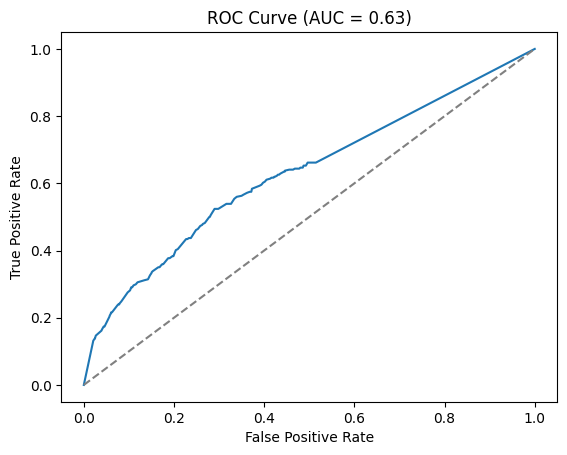

In [ ]:
auc = metrics.roc_auc_score(y_test, y_test_predicted_probability_1)
false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, y_test_predicted_probability_1)


import seaborn as sns
from matplotlib import pyplot as plt

plt.figure()
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {round(auc, 2)})')
plt.show()

### 4. Random Forest (Many trees)

Random Forest Model

An “Ensemble” model Grow many “Decision Trees” → Let the trees “vote” for the best outcome

- Each Decision Tree is train with a different variant of the training data


A random sample of the rows (“bootstrapping”) A random sample of columns/ features

- A more complex and powerful model compared to Logistic Regression and Decision Trees

- Widely used

**Define and Train a Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators = 100) # 100 trees
model_rf.fit(X_train, y_train)


RandomForestClassifier()

**Interpret a Random Forest Model**

Text(0.5, 1.0, 'Feature Importance of Decision Tree')

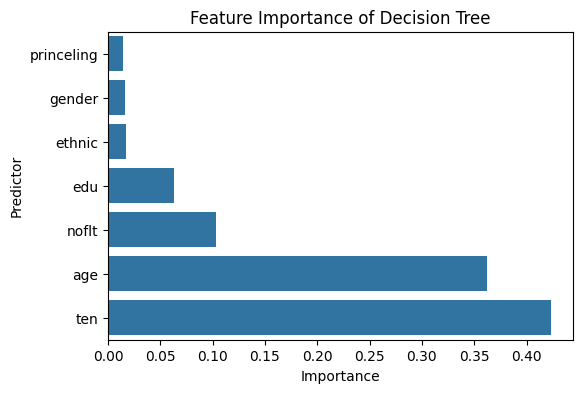

In [ ]:
model_interpretation = pd.DataFrame({"Predictor": X_names, "Importance": model_rf.feature_importances_})
model_interpretation = model_interpretation.sort_values("Importance")

plt.figure(figsize = (6, 4))
sns.barplot(y = "Predictor", x = "Importance", data = model_interpretation)
plt.title("Feature Importance of Decision Tree")


**Evaluate a Random Forest Model**

Same as Logistic Regression and Decision Trees

In [ ]:
THRESHOLD = 0.1
# Get predicted probability for the test set
y_test_predicted_probability = model_rf.predict_proba(X_test)
y_test_predicted_probability
y_test_predicted_probability_1 = y_test_predicted_probability[:, 1]
y_test_predicted = (y_test_predicted_probability_1 > THRESHOLD)
# Calculate Accuracy
print(f"Accuracy: {metrics.accuracy_score(y_test, y_test_predicted)}")
print(f"Precision: {metrics.precision_score(y_test, y_test_predicted)}")
print(f"Recall: {metrics.recall_score(y_test, y_test_predicted)}")
print(f"F1 Score: {metrics.f1_score(y_test, y_test_predicted)}")
print(f"ROC-AUC: {metrics.roc_auc_score(y_test, y_test_predicted_probability_1)}")


Accuracy: 0.7143218623481782
Precision: 0.15283842794759825
Recall: 0.5239520958083832
F1 Score: 0.23664638269100743
ROC-AUC: 0.6734855330797773


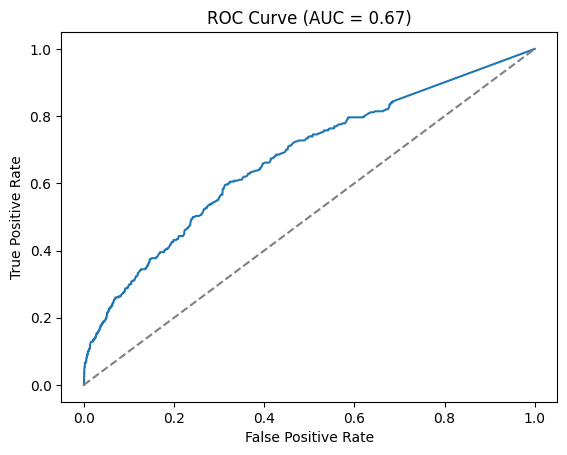

In [ ]:
auc = metrics.roc_auc_score(y_test, y_test_predicted_probability_1)
false_positive_rate, true_positive_rate, _ = metrics.roc_curve(y_test, y_test_predicted_probability_1)


import seaborn as sns
from matplotlib import pyplot as plt

plt.figure()
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {round(auc, 2)})')
plt.show()